# Monte Carlo Portfolio Risk and Scenario Analytics
This project builds a Monte Carlo simulation framework to analyse the risk and return profile of a multi-asset ETF portfolio. The model uses historical returns, volatility, and covariance to simulate possible one-year portfolio outcomes and estimate downside risk metrics such as Value at Risk, Expected Shortfall, probability of loss, and drawdown.

In [1]:
print ("python is working")

python is working


In [2]:
import pandas as pd
import numpy as np
import yfinance as yf

## Portfolio Setup
This section defines a sample multi-asset portfolio using ETFs across US equities, growth equities, government bonds, gold, and the US dollar. Each asset is given a portfolio weight, which determines its contribution to the overall portfolio

In [3]:
portfolio = pd.DataFrame({ 'Ticker':['SPY', 'QQQ', 'TLT','GLD', 'UUP'], 'Asset Class' : ['US Equity', 'US Growth Equity', 'US Government Bonds', 'Gold', 'US Dollar'], 'Weight':[0.35,0.20,0.20,0.15,0.10]})

portfolio

,Ticker,Asset Class,Weight
0,SPY,US Equity,0.35
1,QQQ,US Growth Equity,0.20
2,TLT,US Government Bonds,0.20
3,GLD,Gold,0.15
4,UUP,US Dollar,0.10


In [4]:
total_weight = portfolio['Weight'].sum()
total_weight

np.float64(1.0)

In [5]:
if round(total_weight, 4) != 1.0:
    raise ValueError(f'Portfolio weights must sum to 1. Current sum: {total_weight}')
else:
    print('Portfolio weights sum to 1. Proceeding with calculations.')

Portfolio weights sum to 1. Proceeding with calculations.


In [6]:
tickers = portfolio['Ticker'].tolist()
tickers

['SPY', 'QQQ', 'TLT', 'GLD', 'UUP']

## Market Data and Returns
Historical adjusted closing prices are downloaded for each asset in the portfolio. The price data is cleaned and converted into daily percentage returns, which form the basis for the portfolio return calculations and Monte Carlo simulation.

In [7]:
prices = yf.download(tickers, start="2018-01-01", auto_adjust=True)['Close']
prices.head()

[*********************100%***********************]  5 of 5 completed


Ticker,GLD,QQQ,SPY,TLT,UUP
Date,,,,,
2018-01-02,125.150002,150.057251,235.954300,98.705681,20.009974
2018-01-03,124.820000,151.515305,237.446777,99.177589,20.085234
2018-01-04,125.459999,151.780396,238.447495,99.161888,20.018337
2018-01-05,125.330002,153.304703,240.036591,98.878708,20.035061
2018-01-08,125.309998,153.901230,240.475494,98.815765,20.127041


In [8]:
prices.tail()

Ticker,GLD,QQQ,SPY,TLT,UUP
Date,,,,,
2026-06-25,369.459991,716.380005,734.299988,87.349998,28.480000
2026-06-26,373.630005,706.520020,728.989990,87.360001,28.459999
2026-06-29,368.579987,724.080017,741.000000,87.449997,28.370001
2026-06-30,368.380005,736.400024,746.770020,86.419998,28.410000
2026-07-01,371.880005,726.390015,742.710022,85.470001,28.475000


In [9]:
prices.isna().sum()

Ticker
GLD    0
QQQ    0
SPY    0
TLT    0
UUP    0
dtype: int64

In [10]:
prices = prices.dropna()
prices

Ticker,GLD,QQQ,SPY,TLT,UUP
Date,,,,,
2018-01-02,125.150002,150.057251,235.954300,98.705681,20.009974
2018-01-03,124.820000,151.515305,237.446777,99.177589,20.085234
2018-01-04,125.459999,151.780396,238.447495,99.161888,20.018337
2018-01-05,125.330002,153.304703,240.036591,98.878708,20.035061
2018-01-08,125.309998,153.901230,240.475494,98.815765,20.127041
...,...,...,...,...,...
2026-06-25,369.459991,716.380005,734.299988,87.349998,28.480000
2026-06-26,373.630005,706.520020,728.989990,87.360001,28.459999
2026-06-29,368.579987,724.080017,741.000000,87.449997,28.370001


In [11]:
prices.isna().sum()

Ticker
GLD    0
QQQ    0
SPY    0
TLT    0
UUP    0
dtype: int64

In [12]:
returns = prices.pct_change().dropna()
returns.head()

Ticker,GLD,QQQ,SPY,TLT,UUP
Date,,,,,
2018-01-03,-0.002637,0.009717,0.006325,0.004781,0.003761
2018-01-04,0.005127,0.001750,0.004214,-0.000158,-0.003331
2018-01-05,-0.001036,0.010043,0.006664,-0.002856,0.000835
2018-01-08,-0.000160,0.003891,0.001828,-0.000637,0.004591
2018-01-09,-0.004628,0.000061,0.002263,-0.013373,0.002077


## Historical Portfolio Statistics

The individual asset returns are combined using portfolio weights to calculate the overall daily portfolio return. The portfolio's historical return, volatility, mean asset returns, and covariance matrix are then calculated as inputs for the simulation.

In [13]:
weights = portfolio['Weight'].values
weights

array([0.35, 0.2 , 0.2 , 0.15, 0.1 ])

In [14]:
portfolio_returns = returns @ weights
portfolio_returns.head()

Date
2018-01-03    0.003379
2018-01-04    0.002631
2018-01-05    0.002634
2018-01-08    0.001452
2018-01-09   -0.002953
dtype: float64

In [15]:
portfolio_returns.describe()

count    2134.000000
mean        0.000506
std         0.006916
min        -0.049435
25%        -0.002836
50%         0.000812
75%         0.004177
max         0.058981
dtype: float64

In [16]:
annual_returns = portfolio_returns.mean()*252
annual_volatility = portfolio_returns.std()*np.sqrt(252)
annual_returns, annual_volatility

(np.float64(0.12739576264160737), np.float64(0.10978187688809299))

In [17]:
print(f"Annualised Returns : {annual_returns:.2%}")
print(f"Annualised Volatility : {annual_volatility:.2%}")

Annualised Returns : 12.74%
Annualised Volatility : 10.98%


In [18]:
cov_matrix = returns.cov()
cov_matrix

Ticker,GLD,QQQ,SPY,TLT,UUP
Ticker,,,,,
GLD,0.000112,0.000020,0.000015,0.000023,-0.000021
QQQ,0.000020,0.000227,0.000170,-0.000013,-0.000009
SPY,0.000015,0.000170,0.000146,-0.000016,-0.000007
TLT,0.000023,-0.000013,-0.000016,0.000095,-0.000010
UUP,-0.000021,-0.000009,-0.000007,-0.000010,0.000019


In [19]:
annual_cov_matrix = cov_matrix * 252
annual_cov_matrix

Ticker,GLD,QQQ,SPY,TLT,UUP
Ticker,,,,,
GLD,0.028248,0.005120,0.003700,0.005877,-0.005168
QQQ,0.005120,0.057093,0.042962,-0.003314,-0.002168
SPY,0.003700,0.042962,0.036826,-0.004102,-0.001852
TLT,0.005877,-0.003314,-0.004102,0.023913,-0.002434
UUP,-0.005168,-0.002168,-0.001852,-0.002434,0.004863


In [20]:
mean_returns = returns.mean()
mean_returns

Ticker
GLD    0.000567
QQQ    0.000853
SPY    0.000611
TLT   -0.000020
UUP    0.000175
dtype: float64

In [21]:
annualised_mean_returns = mean_returns * 252
annualised_mean_returns

Ticker
GLD    0.142818
QQQ    0.214892
SPY    0.153902
TLT   -0.005059
UUP    0.044095
dtype: float64

In [22]:
for ticker, value in annualised_mean_returns.items():
    print(f"{ticker}: {value:.2%}")

GLD: 14.28%
QQQ: 21.49%
SPY: 15.39%
TLT: -0.51%
UUP: 4.41%


## Monte Carlo Simulation

The simulation generates 10,000 possible one-year portfolio paths. For each scenario, daily asset returns are randomly generated using historical mean returns and covariance, then combined using portfolio weights to estimate the portfolio value over time.

In [23]:
initial_portfolio_value = 100000
num_simulations = 10000
num_days = 252

In [24]:
mean_returns_array = mean_returns.values
cov_matrix_array = cov_matrix.values
weights_array = portfolio['Weight'].values

In [25]:
simulated_portfolio_values = np.zeros((num_days, num_simulations))

In [26]:
for simulation in range(num_simulations):
    simulated_daily_returns = np.random.multivariate_normal(mean_returns_array, cov_matrix_array, num_days)

    simulated_portfolio_returns = simulated_daily_returns @ weights_array
    simulated_portfolio_values[:, simulation] = initial_portfolio_value*np.cumprod(1 + simulated_portfolio_returns)



In [27]:
simulated_portfolio_values.shape

(252, 10000)

In [28]:
simulated_portfolio_values[:5, :5]

array([[ 99640.84134785,  99580.13432954, 100116.09447438,
        100206.34854284, 100680.01549792],
       [ 98870.15577502, 100803.71221713, 101318.13737091,
         99626.31008105,  98490.36423346],
       [100119.80082665, 101239.82144716, 101514.38453283,
        100530.70853359,  97748.19821239],
       [100298.22225626, 101436.94613231, 101147.92316293,
        101419.66155959,  97883.70701422],
       [100372.7024393 , 100726.17056045, 101443.90147523,
        102575.61471025,  98105.9472862 ]])

In [29]:
final_values = simulated_portfolio_values[-1, :]
final_values[:10]

array([141562.14327095, 106009.36744477, 115283.28776839, 111298.62918422,
       128013.08318729,  85884.76636673, 104978.03027971,  99835.22063126,
       111635.54580264, 122019.63959877])

In [30]:
simulated_returns = final_values / initial_portfolio_value -1
simulated_returns[:10]

array([ 0.41562143,  0.06009367,  0.15283288,  0.11298629,  0.28013083,
       -0.14115234,  0.0497803 , -0.00164779,  0.11635546,  0.2201964 ])

In [31]:
for value in simulated_returns[:10]:
    print(f'Simulated Return: {value:.2%}')

Simulated Return: 41.56%
Simulated Return: 6.01%
Simulated Return: 15.28%
Simulated Return: 11.30%
Simulated Return: 28.01%
Simulated Return: -14.12%
Simulated Return: 4.98%
Simulated Return: -0.16%
Simulated Return: 11.64%
Simulated Return: 22.02%


## Risk Metrics

The simulated final returns are used to calculate key downside risk metrics, including probability of loss, Value at Risk, and Expected Shortfall. These metrics help summarise the likelihood and severity of adverse portfolio outcomes.

In [32]:
print(f'Average Simulated Return:  {simulated_returns.mean():.2%}')
print(f'Best Simulated Return: {simulated_returns.max():.2%}')
print(f'Worst Simulated Return: {simulated_returns.min():.2%}')
print(f'Probability of Loss: {(simulated_returns <0).mean():.2%}')

Average Simulated Return:  13.72%
Best Simulated Return: 70.47%
Worst Simulated Return: -25.24%
Probability of Loss: 13.57%


In [33]:
var_95 = np.percentile(simulated_returns, 5)
print(f'Value at Risk (95% confidence): {var_95:.2%}')

Value at Risk (95% confidence): -5.71%


In [34]:
expected_shortfall_95 = simulated_returns[simulated_returns <= var_95].mean()
print(f'Expected Shortfall (95% confidence): {expected_shortfall_95:.2%}')

Expected Shortfall (95% confidence): -9.85%


In [35]:
var_90 = np.percentile(simulated_returns, 10)
print(f'Value at Risk (90% confidence): {var_90:.2%}')

Value at Risk (90% confidence): -1.81%


In [36]:
expected_shortfall_90 = simulated_returns[simulated_returns <= var_90].mean()
print(f'Exepected Shortfall (90% confidence): {expected_shortfall_90:.2%}')

Exepected Shortfall (90% confidence): -6.71%


## Simulation Visualisations

The forecast cone shows the range of simulated portfolio values over time, while the return distribution chart shows the spread of final one-year returns and highlights downside risk thresholds.

In [37]:
p5 = np.percentile(simulated_portfolio_values, 5, axis=1)
p50 = np.percentile(simulated_portfolio_values, 50, axis=1)
p95 = np.percentile(simulated_portfolio_values, 95, axis=1)

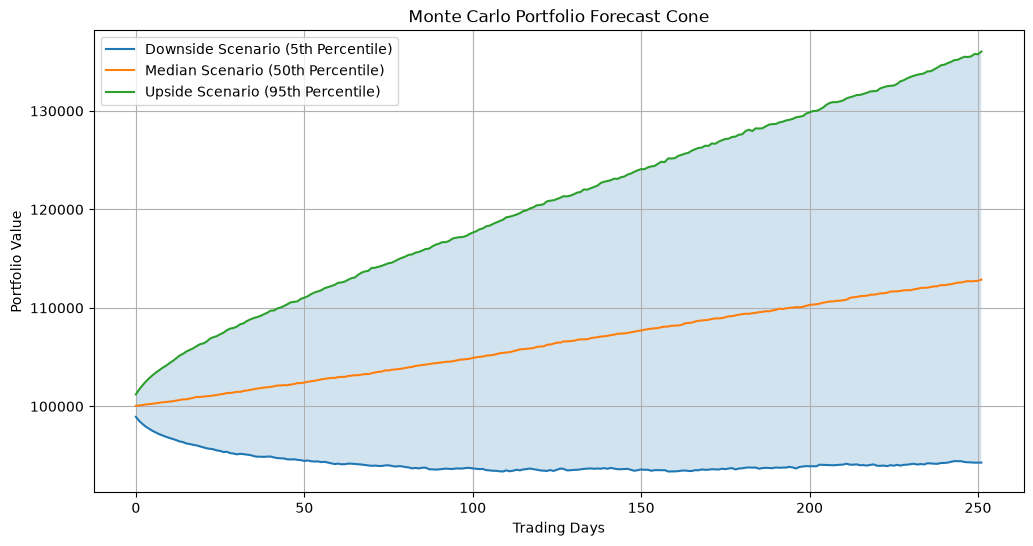

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(p5, label='Downside Scenario (5th Percentile)')
plt.plot(p50, label='Median Scenario (50th Percentile)')
plt.plot(p95, label='Upside Scenario (95th Percentile)')

plt.fill_between(range(num_days), p5, p95, alpha=0.2)

plt.xlabel('Trading Days')
plt.ylabel('Portfolio Value')
plt.title('Monte Carlo Portfolio Forecast Cone')
plt.legend()
plt.grid(True)
plt.show()


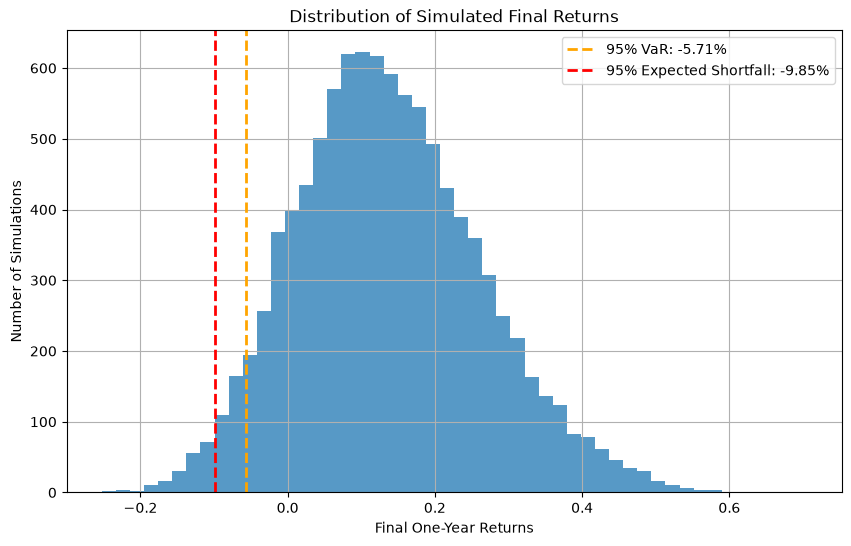

In [39]:
plt.figure(figsize=(10,6))
plt.hist(simulated_returns, bins=50, alpha=0.75)

plt.axvline(var_95, linestyle = '--', linewidth=2, color = 'orange', label = f'95% VaR: {var_95:.2%}')
plt.axvline(expected_shortfall_95, linestyle ='--', linewidth =2, color = 'red', label = f'95% Expected Shortfall: {expected_shortfall_95:.2%}')

plt.title('Distribution of Simulated Final Returns')
plt.xlabel('Final One-Year Returns')
plt.ylabel('Number of Simulations')
plt.legend()
plt.grid(True)

plt.show()


## Final Risk Summary
The key simulation and risk metrics are summarised in a single table. This makes it easier to interpret the overall risk and return profile of the portfolio.

In [40]:
summary = pd.DataFrame({ 'Metric':['Annualised Historical Return', 'Annualised Historical Volatility', 'Average Simulated Return', 'Best Simulated Return', 'Worst Simulated Return', 'Probability of Loss', 'Value at Risk (95%)', 'Expected Shortfall (95%)'], 'Value':[f'{annual_returns:.2%}', f'{annual_volatility:.2%}', f'{simulated_returns.mean():.2%}', f'{simulated_returns.max():.2%}', f'{simulated_returns.min():.2%}', f'{(simulated_returns <0).mean():.2%}', f'{var_95:.2%}', f'{expected_shortfall_95:.2%}']})
summary

,Metric,Value
0,Annualised Historical Return,12.74%
1,Annualised Historical Volatility,10.98%
2,Average Simulated Return,13.72%
3,Best Simulated Return,70.47%
4,Worst Simulated Return,-25.24%
5,Probability of Loss,13.57%
6,Value at Risk (95%),-5.71%
7,Expected Shortfall (95%),-9.85%


# Extension 1: Drawdown Analysis

This section extends the MVP by analysing path-dependent downside risk. Instead of only looking at final one-year outcomes, drawdown analysis measures how far the portfolio falls from previous peaks during the investment period.

The section calculates historical portfolio drawdown, identifies the maximum historical drawdown, and visualises drawdown over time to show when the portfolio experienced its deepest declines.

In [41]:
historical_portfolio_values = initial_portfolio_value * (1 + portfolio_returns).cumprod()
historical_running_peak = historical_portfolio_values.cummax()
historical_drawdown = (historical_portfolio_values - historical_running_peak) / historical_running_peak
historical_drawdown.head()

Date
2018-01-03    0.000000
2018-01-04    0.000000
2018-01-05    0.000000
2018-01-08    0.000000
2018-01-09   -0.002953
dtype: float64

In [42]:
max_historical_drawdown = historical_drawdown.min()
print(f'Maximum Historical Drawdown : {max_historical_drawdown:.2%}')

Maximum Historical Drawdown : -18.83%


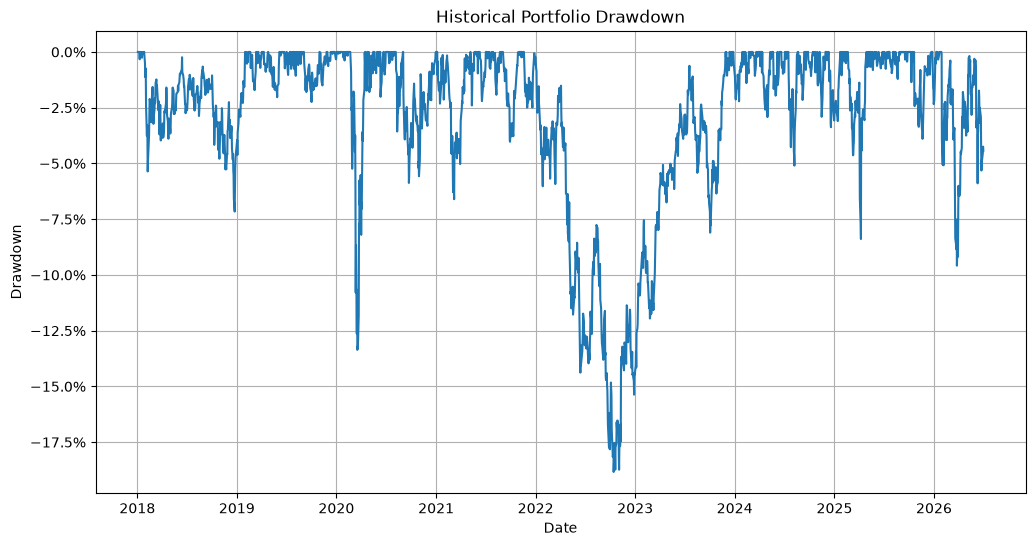

In [43]:
import matplotlib.ticker as mticker

plt.figure(figsize=(12,6))
plt.plot(historical_drawdown)

plt.title('Historical Portfolio Drawdown')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.grid(True)

plt.show()


In [44]:
simulated_running_peaks = np.maximum.accumulate(simulated_portfolio_values, axis=0)
simulated_drawdowns = (simulated_portfolio_values - simulated_running_peaks) / simulated_running_peaks
simulated_drawdowns.shape

(252, 10000)

In [45]:
max_simulated_drawdown = simulated_drawdowns.min(axis=0)
max_simulated_drawdown[:10]

array([-0.04907492, -0.08664779, -0.09844118, -0.08336167, -0.11185882,
       -0.18441188, -0.10920221, -0.10888199, -0.06889395, -0.06285396])

In [46]:
print(f'Average Maximum Simulated Drawdown: {max_simulated_drawdown.mean():.2%}')
print(f'Worst Maximum Simulated Drawdown: {max_simulated_drawdown.min():.2%}')
print(f'Best Maximum Simulated Drawdown: {max_simulated_drawdown.max():.2%}')
print(f'95th Percentile Drawdown Risk Threshold: {np.percentile(max_simulated_drawdown, 5):.2%}')

Average Maximum Simulated Drawdown: -8.59%
Worst Maximum Simulated Drawdown: -27.49%
Best Maximum Simulated Drawdown: -2.39%
95th Percentile Drawdown Risk Threshold: -15.01%


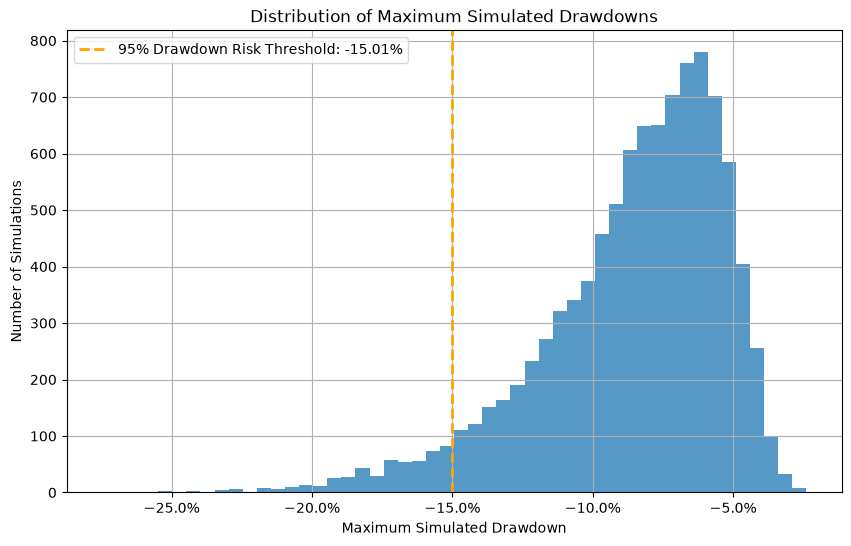

In [47]:
plt.figure(figsize=(10,6))
plt.hist(max_simulated_drawdown, bins=50, alpha=0.75)

plt.axvline(np.percentile(max_simulated_drawdown, 5), linestyle = '--', linewidth=2, color = 'orange', label = f'95% Drawdown Risk Threshold: {np.percentile(max_simulated_drawdown, 5):.2%}')
plt.xlabel('Maximum Simulated Drawdown')
plt.ylabel('Number of Simulations')
plt.title('Distribution of Maximum Simulated Drawdowns')
plt.gca().xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.legend()
plt.grid(True)

plt.show()

In [48]:
drawdown_summary = pd.DataFrame({ 'Metric':['Historical Maximum Drawdown','Average Maximum Simulated Drawdown', 'Worst Maximum Simulated Drawdown', 'Best Maximum Simulated Drawdown', '95% Drawdown Risk Threshold'], 'Value':[f'{max_historical_drawdown:.2%}', f'{max_simulated_drawdown.mean():.2%}', f'{max_simulated_drawdown.min():.2%}', f'{max_simulated_drawdown.max():.2%}', f'{np.percentile(max_simulated_drawdown, 5):.2%}']})

drawdown_summary

,Metric,Value
0,Historical Maximum Drawdown,-18.83%
1,Average Maximum Simulated Drawdown,-8.59%
2,Worst Maximum Simulated Drawdown,-27.49%
3,Best Maximum Simulated Drawdown,-2.39%
4,95% Drawdown Risk Threshold,-15.01%


## Drawdown Analysis Conclusion

The drawdown analysis adds a path-dependent view of portfolio risk. While the Monte Carlo MVP focused mainly on final one-year outcomes, drawdown analysis shows how severe losses could become during the investment period before any recovery.

Historically, the portfolio experienced a maximum drawdown of around 18.8%. Across the simulated one-year scenarios, the average maximum drawdown was around 8.6%, while the worst simulated path produced a drawdown of around 26.1%. The 95% drawdown risk threshold suggests that in the worst 5% of simulated scenarios, the portfolio could experience a maximum drawdown worse than roughly 14.8%.

This strengthens the project by showing not only where the portfolio may finish, but also how much downside pressure an investor may experience along the way.

# Extension 2: Stress Testing
This section extends the portfolio risk model by applying market shock scenarios to the portfolio. Stress testing helps deduce how the portfolio may behave under unusual market conditions like equity sell-offs, bond-market shocks, risk-off moves or currency strength. The shocks below are manual assumptions, not historical assumptions.

In [49]:
stress_scenarios = pd.DataFrame({'Scenario': ['Equity Sell-Off', 'Bond Market Sell-Off / Rates Shock', 'Risk-Off Flight to Safety', 'US Dollar Strength Shock', 'Broad Multi-Asset Market Stress'], 'SPY': [-0.10, -0.03, -0.08, -0.04, -0.12], 'QQQ': [-0.15, -0.05, -0.12, -0.06, -0.18], 'TLT': [0.03, -0.10, 0.06, -0.02, -0.08], 'GLD': [0.04, -0.02, 0.07, -0.03, 0.02], 'UUP': [0.02, 0.03, 0.04, 0.06, 0.04] })

stress_scenarios

,Scenario,SPY,QQQ,TLT,GLD,UUP
0,Equity Sell-Off,-0.10,-0.15,0.03,0.04,0.02
1,Bond Market Sell-Off / Rates Shock,-0.03,-0.05,-0.10,-0.02,0.03
2,Risk-Off Flight to Safety,-0.08,-0.12,0.06,0.07,0.04
3,US Dollar Strength Shock,-0.04,-0.06,-0.02,-0.03,0.06
4,Broad Multi-Asset Market Stress,-0.12,-0.18,-0.08,0.02,0.04


In [50]:
stress_returns = stress_scenarios[tickers] @ weights_array

stress_results = pd.DataFrame({'Scenario': stress_scenarios['Scenario'], 'Portfolio Stress Return': stress_returns, 'Portfolio Value After Stress': initial_portfolio_value * (1  + stress_returns), 'Portfolio P&L': initial_portfolio_value *stress_returns})

stress_results

,Scenario,Portfolio Stress Return,Portfolio Value After Stress,Portfolio P&L
0,Equity Sell-Off,-0.0510,94900.0,-5100.0
1,Bond Market Sell-Off / Rates Shock,-0.0405,95950.0,-4050.0
2,Risk-Off Flight to Safety,-0.0255,97450.0,-2550.0
3,US Dollar Strength Shock,-0.0285,97150.0,-2850.0
4,Broad Multi-Asset Market Stress,-0.0870,91300.0,-8700.0


In [51]:
def format_dollars(value):
    if value < 0:
        return f'-${abs(value):,.2f}'
    else: return f'${value:,.2f}'

In [52]:
formatted_stress_results = stress_results.copy()
formatted_stress_results['Portfolio Stress Return'] = formatted_stress_results['Portfolio Stress Return'].map('{:.2%}'.format)
formatted_stress_results['Portfolio Value After Stress'] = formatted_stress_results['Portfolio Value After Stress'].map(format_dollars)
formatted_stress_results['Portfolio P&L'] = formatted_stress_results['Portfolio P&L'].map(format_dollars)
formatted_stress_results

,Scenario,Portfolio Stress Return,Portfolio Value After Stress,Portfolio P&L
0,Equity Sell-Off,-5.10%,"$94,900.00","-$5,100.00"
1,Bond Market Sell-Off / Rates Shock,-4.05%,"$95,950.00","-$4,050.00"
2,Risk-Off Flight to Safety,-2.55%,"$97,450.00","-$2,550.00"
3,US Dollar Strength Shock,-2.85%,"$97,150.00","-$2,850.00"
4,Broad Multi-Asset Market Stress,-8.70%,"$91,300.00","-$8,700.00"


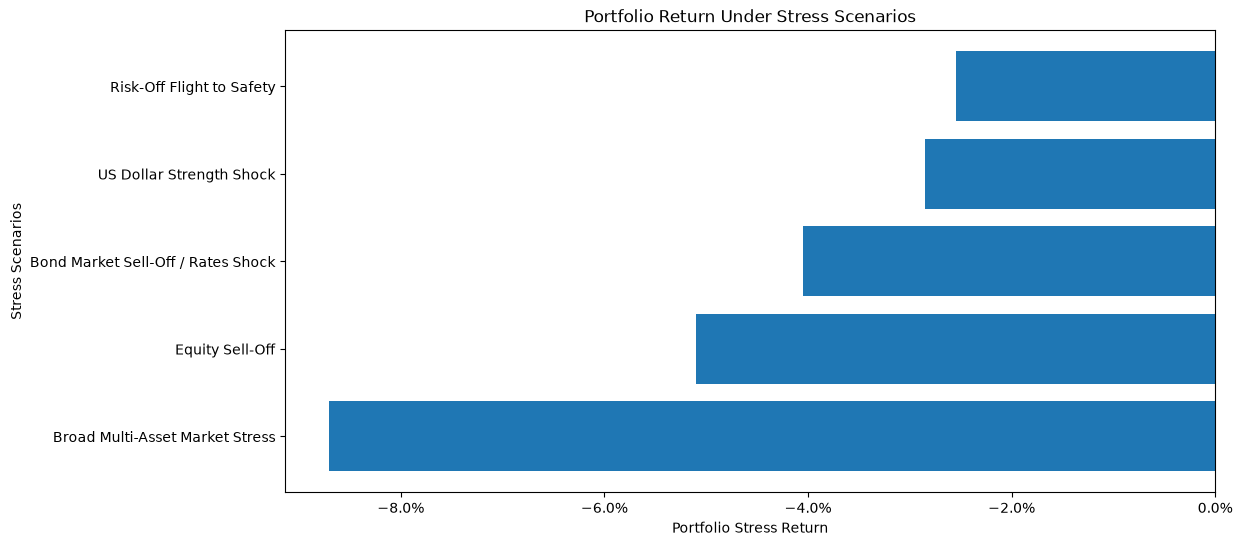

In [53]:
stress_results_sorted = stress_results.sort_values('Portfolio Stress Return')

plt.figure(figsize=(12,6))

plt.barh(stress_results_sorted['Scenario'], stress_results_sorted['Portfolio Stress Return'])

plt.title('Portfolio Return Under Stress Scenarios')
plt.ylabel('Stress Scenarios')
plt.xlabel('Portfolio Stress Return')
plt.gca().xaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.show()

In [54]:
worst_stress_scenario = stress_results.loc[stress_results['Portfolio Stress Return'].idxmin()]
worst_stress_scenario

Scenario                        Broad Multi-Asset Market Stress
Portfolio Stress Return                                  -0.087
Portfolio Value After Stress                            91300.0
Portfolio P&L                                           -8700.0
Name: 4, dtype: object

In [55]:
print(f'Worst Stress Scenario: {worst_stress_scenario["Scenario"]}')
print(f'Portfolio Stress Return: {worst_stress_scenario["Portfolio Stress Return"]:.2%}')
print(f'Portfolio Value After Stress: ${worst_stress_scenario["Portfolio Value After Stress"]:,.2f}')
print(f'Portfolio P&L: -${abs(worst_stress_scenario["Portfolio P&L"]):,.2f}')


Worst Stress Scenario: Broad Multi-Asset Market Stress
Portfolio Stress Return: -8.70%
Portfolio Value After Stress: $91,300.00
Portfolio P&L: -$8,700.00


## Stress Testing Conclusion

The stress testing module applies analyst-defined market shock scenarios to the portfolio to assess how it may respond under specific adverse market conditions.

The results show that the broad multi-asset market stress scenario produces the largest portfolio loss, with the portfolio falling by roughly 8.7% from its initial value. This scenario is the  worst because both equities and bonds decline simultaneously, reducing the benefit of diversification.

The stress testing extension strengthens the project by moving beyond random Monte Carlo simulations and showing how the portfolio behaves under deliberate market narratives, such as equity sell-offs, rates shocks, risk-off moves, and US dollar strength. These scenarios are hypothetical and not based on realised historical returns.

# Extension 3: Historically Calibrated Stress Testing
This section extends the stress testing framework by using actual historical market periods to analyse portfolio stress scenarios. Rather than manually assuming asset shocks, the model calculates how each asset performed during known stress periods and applies those realised returns to the portfolio.

This makes the stress-testing module more evidence based and allows the portfolio to be tested against real historical market environments.

In [56]:
historical_stress_periods = pd.DataFrame({'Scenario': ['Covid-19 Market Crash', '2022 Inflation and Rates Shock', '2023 Regional Banking Stress' ], 'Start Date':['2020-02-19', '2022-01-03', '2023-03-08'], 'End Date':['2020-03-23', '2022-10-14', '2023-03-24']})

historical_stress_periods

,Scenario,Start Date,End Date
0,Covid-19 Market Crash,2020-02-19,2020-03-23
1,2022 Inflation and Rates Shock,2022-01-03,2022-10-14
2,2023 Regional Banking Stress,2023-03-08,2023-03-24


In [57]:
historical_stress_return_rows = []

for _, row in historical_stress_periods.iterrows():
    scenario_name = row['Scenario']
    start_date = row['Start Date']
    end_date = row['End Date']

    start_prices= prices.loc[start_date]
    end_prices = prices.loc[end_date]

    asset_return = (end_prices-start_prices) / start_prices
    asset_return['Scenario'] = scenario_name

    historical_stress_return_rows.append(asset_return)
    historical_stress_returns = pd.DataFrame(historical_stress_return_rows)

historical_stress_returns



Ticker,GLD,QQQ,SPY,TLT,UUP,Scenario
0,-0.036168,-0.279166,-0.337173,0.142343,0.039391,Covid-19 Market Crash
1,-0.091190,-0.347654,-0.242698,-0.305882,0.181078,2022 Inflation and Rates Shock
2,0.089652,0.045501,-0.004160,0.049401,-0.020273,2023 Regional Banking Stress


In [58]:
historical_stress_portfolio_returns = historical_stress_returns[tickers] @ weights_array
historical_stress_results = pd.DataFrame({'Scenario': historical_stress_returns['Scenario'], 'Portfolio Stress Return': historical_stress_portfolio_returns, 'Portfolio Value After Stress': initial_portfolio_value * (1 + historical_stress_portfolio_returns), 'Portfolio P&L': initial_portfolio_value * historical_stress_portfolio_returns})
historical_stress_results

,Scenario,Portfolio Stress Return,Portfolio Value After Stress,Portfolio P&L
0,Covid-19 Market Crash,-0.146861,85313.882732,-14686.117268
1,2022 Inflation and Rates Shock,-0.211222,78877.754737,-21122.245263
2,2023 Regional Banking Stress,0.028945,102894.488823,2894.488823


In [59]:
formatted_historical_stress_results = historical_stress_results.copy()
formatted_historical_stress_results['Portfolio Stress Return'] = formatted_historical_stress_results['Portfolio Stress Return'].map('{:.2%}'.format)
formatted_historical_stress_results['Portfolio Value After Stress'] = formatted_historical_stress_results['Portfolio Value After Stress'].map(format_dollars)
formatted_historical_stress_results['Portfolio P&L'] = formatted_historical_stress_results['Portfolio P&L'].map(format_dollars)
formatted_historical_stress_results

,Scenario,Portfolio Stress Return,Portfolio Value After Stress,Portfolio P&L
0,Covid-19 Market Crash,-14.69%,"$85,313.88","-$14,686.12"
1,2022 Inflation and Rates Shock,-21.12%,"$78,877.75","-$21,122.25"
2,2023 Regional Banking Stress,2.89%,"$102,894.49","$2,894.49"


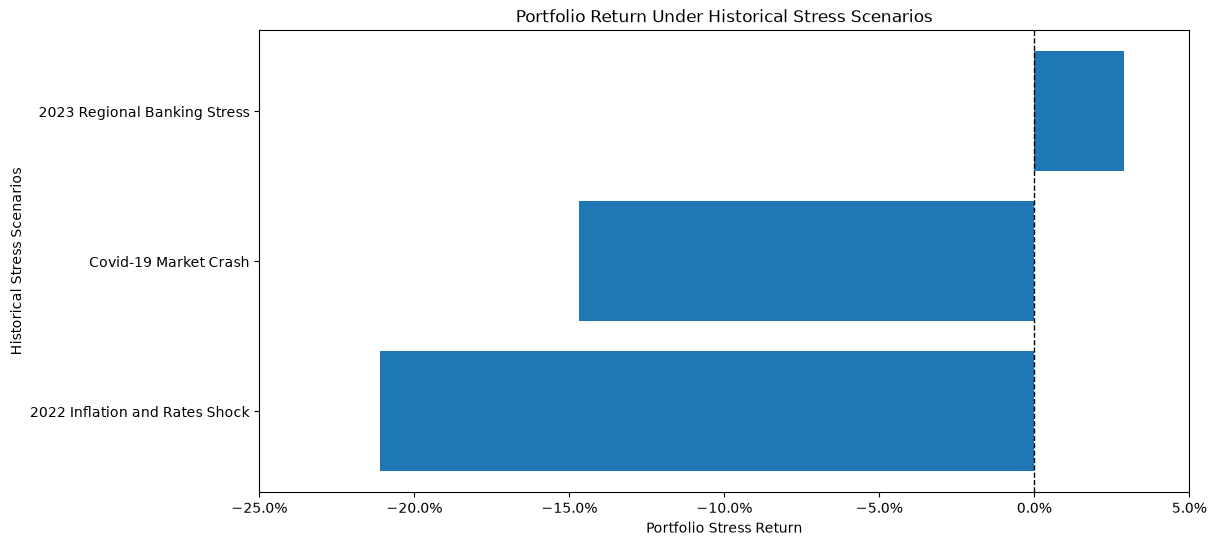

In [60]:
historical_stress_results_sorted = historical_stress_results.sort_values('Portfolio Stress Return')
plt.figure(figsize=(12,6))
plt.barh(historical_stress_results_sorted['Scenario'], historical_stress_results_sorted['Portfolio Stress Return'])

plt.axvline(0, color ='black', linestyle ='--', linewidth= 1)
plt.title('Portfolio Return Under Historical Stress Scenarios')
plt.ylabel('Historical Stress Scenarios')
plt.xlabel('Portfolio Stress Return')
plt.gca().xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.xlim(-0.25,0.05)

plt.show()

In [61]:
worst_historical_stress_scenario = historical_stress_results.loc[historical_stress_results['Portfolio Stress Return'].idxmin()]
worst_historical_stress_scenario

Scenario                        2022 Inflation and Rates Shock
Portfolio Stress Return                              -0.211222
Portfolio Value After Stress                      78877.754737
Portfolio P&L                                    -21122.245263
Name: 1, dtype: object

In [62]:
print(f"Worst Historical Stress Scenario: {worst_historical_stress_scenario['Scenario']}")
print(f"Portfolio Stress Return: {worst_historical_stress_scenario['Portfolio Stress Return']:.2%}")
print(f"Portfolio Value After Stress: ${worst_historical_stress_scenario['Portfolio Value After Stress']:,.2f}")
print(f"Portfolio P&L: -${abs(worst_historical_stress_scenario['Portfolio P&L']):,.2f}")


Worst Historical Stress Scenario: 2022 Inflation and Rates Shock
Portfolio Stress Return: -21.12%
Portfolio Value After Stress: $78,877.75
Portfolio P&L: -$21,122.25


## Historical Stress Insight: Diversification Breakdown
Here the 2022 Inflation and Rates Shock showcases a real-life example of broad multi-asset stress. During this period both equities and long-duration bonds declined, which nullified the usual benefit of holding bonds alongside equities. This mirrors the analyst-defined broad multi-asset stress scenario mentioned in the extension above. However it is more evidence-based because the shocks are calculated from actual historical asset returns.

# Extension 4: Volatility Sensitivity Analysis
This section tests how portfolio risk reacts to an increase in market volatility. In stressed markets, volatility often rises, meaning asset returns become more unstable and downside outcomes can become more severe. The analysis scales the historical covariance matrix by different volatility multipliers and reruns the Monte-Carlo simulation. This allows the model to compare how Value at Risk, Expected Shortfall, drawdown, and simulated portfolio outcomes change under higher-volatility market regimes.

In [63]:
volatility_multipliers = [1.0, 1.5, 2.0, 3.0]

volatility_multipliers

[1.0, 1.5, 2.0, 3.0]

In [64]:
volatility_sensitivity_results = []
for multiplier in volatility_multipliers:
    scaled_cov_matrix = cov_matrix_array * multiplier

    simulated_values_vol = np.zeros((num_days, num_simulations))

    for simulation in range(num_simulations):
        simulated_daily_returns = np.random.multivariate_normal(mean_returns_array, scaled_cov_matrix, num_days)

        simulated_portfolio_returns = simulated_daily_returns @ weights_array

        simulated_values_vol[:, simulation] = initial_portfolio_value * np.cumprod(1+simulated_portfolio_returns)

    final_values_vol = simulated_values_vol[-1,:]
    simulated_returns_vol = (final_values_vol - initial_portfolio_value) / initial_portfolio_value

    var_95_vol = np.percentile(simulated_returns_vol,5)
    expected_shortfall_95_vol = simulated_returns_vol[simulated_returns_vol <= var_95_vol].mean()
    probability_of_loss_vol = (simulated_returns_vol < 0).mean()

    running_peaks_vol = np.maximum.accumulate(simulated_values_vol,axis=0)
    drawdowns_vol = (simulated_values_vol - running_peaks_vol)/ running_peaks_vol
    max_drawdowns_vol = drawdowns_vol.min(axis=0)

    volatility_sensitivity_results.append ({'Volatility Multiplier': multiplier, 'Average Simulated Return' : simulated_returns_vol.mean(), 'Probability of Loss' : probability_of_loss_vol, '95% VaR': var_95_vol, '95% Expected Shortfall': expected_shortfall_95_vol, 'Average Max Drawdown': max_drawdowns_vol.mean(), '95% Drawdown Risk Threshold': np.percentile(max_drawdowns_vol,5)})

volatility_sensitivity_results = pd.DataFrame(volatility_sensitivity_results)

volatility_sensitivity_results


    




,Volatility Multiplier,Average Simulated Return,Probability of Loss,95% VaR,95% Expected Shortfall,Average Max Drawdown,95% Drawdown Risk Threshold
0,1.0,0.136275,0.1341,-0.056408,-0.098907,-0.086053,-0.149607
1,1.5,0.136674,0.1855,-0.094826,-0.143674,-0.110714,-0.193894
2,2.0,0.136936,0.2268,-0.131118,-0.182623,-0.131773,-0.227823
3,3.0,0.133123,0.2874,-0.186528,-0.247120,-0.167081,-0.286796


In [65]:
formatted_volatility_sensitivity_results = volatility_sensitivity_results.copy()
formatted_volatility_sensitivity_results['Average Simulated Return'] = formatted_volatility_sensitivity_results['Average Simulated Return'].map('{:.2%}'.format)
formatted_volatility_sensitivity_results['Probability of Loss'] = formatted_volatility_sensitivity_results['Probability of Loss'].map('{:.2%}'.format)
formatted_volatility_sensitivity_results['95% VaR'] = formatted_volatility_sensitivity_results['95% VaR'].map('{:.2%}'.format)
formatted_volatility_sensitivity_results['95% Expected Shortfall'] = formatted_volatility_sensitivity_results['95% Expected Shortfall'].map('{:.2%}'.format)
formatted_volatility_sensitivity_results['Average Max Drawdown'] = formatted_volatility_sensitivity_results['Average Max Drawdown'].map('{:.2%}'.format)
formatted_volatility_sensitivity_results['95% Drawdown Risk Threshold'] = formatted_volatility_sensitivity_results['95% Drawdown Risk Threshold'].map('{:.2%}'.format)

formatted_volatility_sensitivity_results

,Volatility Multiplier,Average Simulated Return,Probability of Loss,95% VaR,95% Expected Shortfall,Average Max Drawdown,95% Drawdown Risk Threshold
0,1.0,13.63%,13.41%,-5.64%,-9.89%,-8.61%,-14.96%
1,1.5,13.67%,18.55%,-9.48%,-14.37%,-11.07%,-19.39%
2,2.0,13.69%,22.68%,-13.11%,-18.26%,-13.18%,-22.78%
3,3.0,13.31%,28.74%,-18.65%,-24.71%,-16.71%,-28.68%


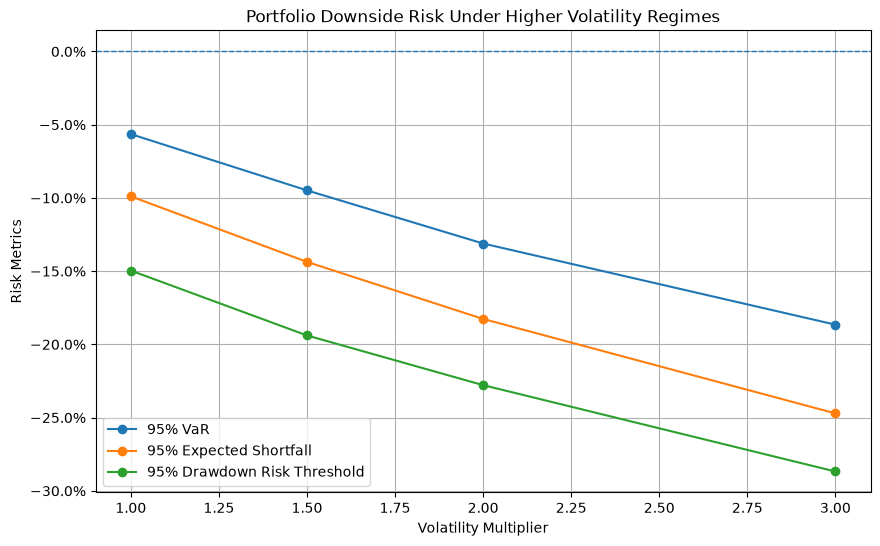

In [66]:
plt.figure(figsize=(10,6))

plt.plot(volatility_sensitivity_results['Volatility Multiplier'], volatility_sensitivity_results['95% VaR'], marker = 'o', label='95% VaR')
plt.plot(volatility_sensitivity_results['Volatility Multiplier'], volatility_sensitivity_results['95% Expected Shortfall'], marker = 'o', label='95% Expected Shortfall')
plt.plot(volatility_sensitivity_results['Volatility Multiplier'], volatility_sensitivity_results['95% Drawdown Risk Threshold'], marker = 'o', label='95% Drawdown Risk Threshold')

plt.axhline(0, linestyle='--',  linewidth=1)
plt.title('Portfolio Downside Risk Under Higher Volatility Regimes')
plt.xlabel('Volatility Multiplier')
plt.ylabel('Risk Metrics')
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.legend()
plt.grid(True)
plt.show()

## Volatility Sensitivity Analysis Conclusion

The volatility sensitivity analysis shows that portfolio downside risk becomes more severe as market volatility increases. Although the expected return assumption is held constant, scaling the covariance matrix widens the distribution of simulated outcomes.

As volatility rises from normal levels to a severe volatility regime, 95% VaR, Expected Shortfall, and drawdown risk all deteriorate. This demonstrates that the portfolio is sensitive to volatility regimes, which means that under more volatile market conditions, the portfolio is more exposed to extreme downside outcomes and deeper drawdowns during the simulation period.

This section strengthens the risk framework by showing how the portfolio may behave not only under specific stress events, but also under broader changes in market volatility.

# Key findings

This Monte Carlo Simulation suggests that this portfolio has a positive expected one-year return, but still carries downside risk. The 95% VaR and Expected Shortfall results indicate that losses can become substantial in the left tail of the distribution. The drawdown analysis adds a path-dependent view of risk. It tells us that whilst the portfolio may end certain years positively, investors could still experience large interim losses from previous peaks.

The stress testing results show the portfolio is most vulnerable when scenarios cause diversification to break down. For example the 2022 inflation and rates shock produced the biggest stress loss because both equities and long-duration bonds declined simultaneously. The volatility analysis highlights that downside risk becomes more severe when market volatility increases. As volatility increases, the downside tail widens and drawdowns become deeper, which indicates the importance of tracking volatility when analysing portfolio risk.